<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Computer-Vision/blob/main/Practicals/CR_Pract_11ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
%cd "/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV"

/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV


Contour 21: area=85.5, perimeter=65.4, centroid=(124,250)
Contour 29: area=421.5, perimeter=142.2, centroid=(8,254)
Contour 83: area=509.5, perimeter=129.2, centroid=(260,8)
Contour 85: area=43021.5, perimeter=2583.1, centroid=(178,131)
Contour 90: area=91.0, perimeter=53.5, centroid=(91,234)
Contour 93: area=237.0, perimeter=104.1, centroid=(234,222)
Contour 102: area=71.5, perimeter=49.6, centroid=(157,195)
Contour 105: area=73.0, perimeter=48.8, centroid=(95,190)
Contour 130: area=344.0, perimeter=142.5, centroid=(148,145)
Contour 138: area=94.5, perimeter=60.2, centroid=(81,124)
Contour 150: area=2739.5, perimeter=401.0, centroid=(194,182)
Contour 162: area=94.0, perimeter=65.3, centroid=(85,103)
Contour 163: area=127.0, perimeter=60.8, centroid=(210,100)
Contour 179: area=55.0, perimeter=48.8, centroid=(106,70)
Contour 186: area=344.0, perimeter=87.3, centroid=(207,58)
Contour 189: area=930.5, perimeter=285.3, centroid=(84,65)
Contour 202: area=5596.5, perimeter=742.0, centroid=(2

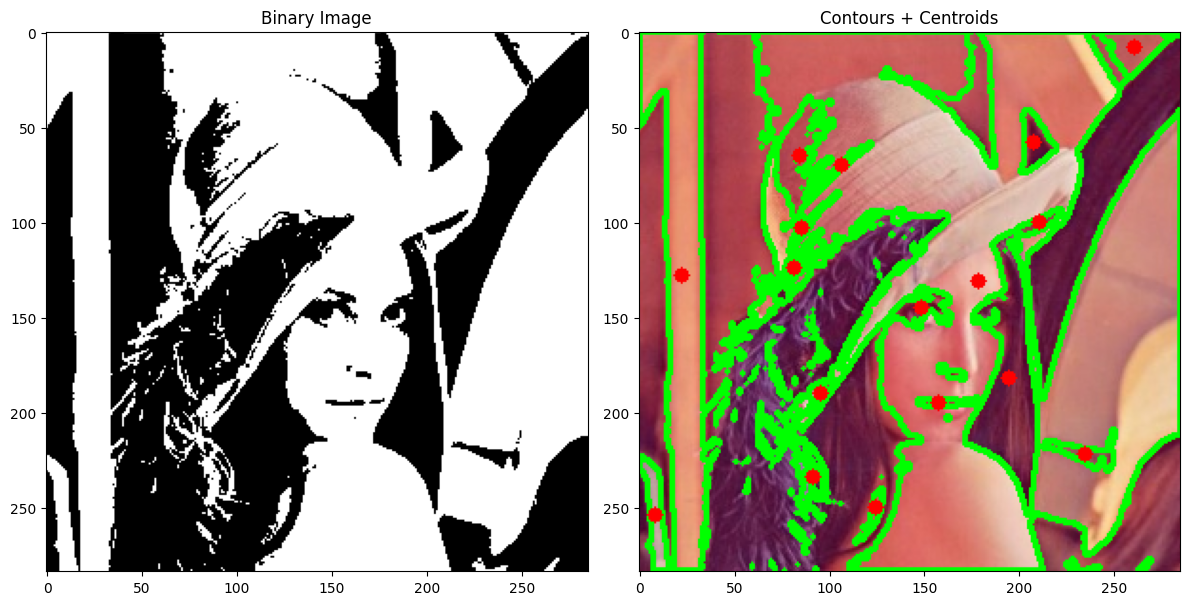

In [21]:
# Load grayscale image
img = cv2.imread('lena.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 1: Convert to a binary image (Otsu's thresholding)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Step 2: Find contours
contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Step 3: Draw contours and label each with area + centroid
output = img.copy()
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    if area < 50:      	# skip tiny noisy contours
        continue
    M = cv2.moments(c)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    cv2.circle(output, (cx, cy), 4, (0, 0, 255), -1)
    print(f'Contour {i}: area={area:.1f}, perimeter={perimeter:.1f}, centroid=({cx},{cy})')

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(binary, cmap='gray'), plt.title('Binary Image')
plt.subplot(1, 2, 2), plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)), plt.title('Contours + Centroids')
plt.tight_layout()
plt.show()

In [13]:
!ls

 CR_Pract-10.ipynb   CR_Pract-6.ipynb   CV_pract-1.ipynb   CV_Pract-9.ipynb
 CR_Pract-11ipynb    CR_Pract-7.ipynb   CV_pract-2.ipynb  'Data For CV'
 CR_Pract-4.ipynb    CR_Pract-8.ipynb   CV_Pract-3.ipynb
